# PGProv Provenance Overhead Analysis

This jupyter notebook includes a detailed analysis of the overhead incurred by the provenance computation over baseline queries using the FinBench (sf 0.3, 1, 3, and 10) and SNB-BI (sf 1, 3, and 10) benchmarks. The analysis follows the following order.

1. Analysis of the execution times of provenance computation across queries and scale factors
2. Analysis of the provenance overhead
    1. Absolute provenance overhead
    2. Percenatge provenance overhead (relative to baseline queries)
3. Analysis of result size against provenance overhead

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import numpy as np

plt.rcParams["font.family"] = "DejaVu Serif"

pd.set_option('display.float_format', '{:.0f}'.format)

plt.style.use("default")
plt.rcParams.update({
    "font.size": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

In [51]:
# --------------------------------------------------
# FinBench: Query Name Mappings and Query Groups
# --------------------------------------------------

finbench_query_name = {
    1.3: 'RJ-1', 2.3: 'RJ-2', 3: 'J-1', 4.3: 'RJ-3', 5: 'S-1',
    6: 'S-2', 7.3: 'RJ-4', 8: 'J-2', 9.3: 'R-1', 10: 'MM-1',
    11: 'S-3', 12: 'S-4', 13: 'MM-2', 14: 'MM-3', 15: 'S-5',
    16: 'S-6', 17: 'S-7', 18: 'F-1*', 19: 'SQ-1*', 20: 'SQU-1*'
}

finbench_query_groups = {
    "Simple":       ['S-1', 'S-2', 'S-3', 'S-4', 'S-5', 'S-6', 'S-7', 'J-1', 'J-2'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3', 'F-1*'],
    "Complex":      ['R-1', 'RJ-1', 'RJ-2', 'RJ-3', 'RJ-4', 'SQ-1*', 'SQU-1*']
}

finbench_query_to_group = {}
for group, queries in finbench_query_groups.items():
    for q in queries:
        finbench_query_to_group[q] = group

finbench_query_order = (
        finbench_query_groups["Simple"] +
        finbench_query_groups["Intermediate"] +
        finbench_query_groups["Complex"]
)

# --------------------------------------------------
# SNB-BI: Query Name Mappings and Query Groups
# --------------------------------------------------

snb_query_name = {
    1: 'MM-1', 2: 'MM-2', 3: 'R-1', 4: 'SQU-1', 5: 'MM-3',
    6: 'MM-4', 7: 'J-1', 8: 'MM-5', 9: 'R-2', 10: 'MMJ-1',
    11: 'MMJ-2', 12: 'R-3', 13: 'MM-6', 14: 'MMJ-3', 15: 'SQU-2',
    16: 'MMJ-4', 17: 'S-1', 18: 'J-2', 19: 'J-3', 20: 'F-1*'
}

snb_query_groups = {
    "Simple": ['S-1', 'J-1', 'J-2', 'J-3'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3',
                     'MM-4', 'MM-5', 'MM-6', 'F-1*'],
    "Complex": ['MMJ-1', 'MMJ-2', 'MMJ-3', 'MMJ-4',
                'R-1', 'R-2', 'R-3', 'SQU-1', 'SQU-2']
}

snb_query_to_group = {}
for group, queries in snb_query_groups.items():
    for q in queries:
        snb_query_to_group[q] = group

snb_query_order = (
        snb_query_groups["Simple"] +
        snb_query_groups["Intermediate"] +
        snb_query_groups["Complex"]
)

In [52]:
# --------------------------------------------------
# Query Size Computation
# --------------------------------------------------
# label_size    : Total number of labels referenced in a query
# property_size : Total number of properties referenced in a query
# query_size    : label_size + property_size
# --------------------------------------------------

# --------------------------------------------------
# FinBench
# --------------------------------------------------

finbench_query_label_size ={
    1.3 :  5,  2.3 : 7,  3.0 : 6,  4.3: 5,  5.0 :5,
    6.0 : 7,  7.3: 6,  8.: 8 ,  9.3: 4, 10.: 5 ,
    11.: 7 ,12.: 1 , 13.: 5 , 14.: 5 , 15. : 3,
    16. : 3, 17.: 5 , 18.: 5 , 19.:5 , 20.: 5

}

finbench_query_property_size ={
    1.3 :  6,  2.3 : 5,  3. : 8,  4.3: 1,  5. :7,
    6. : 5,  7.3: 4,  8.: 8 ,  9.3: 3, 10.: 3 ,
    11.: 4 ,12.: 4 , 13.: 5 , 14.: 4 , 15. : 4,
    16. : 4, 17.: 5 , 18.: 5 , 19.:9 , 20.: 5

}

finbench_query_size = {}

for key in finbench_query_label_size.keys():
    finbench_query_size[key] = finbench_query_label_size[key]+ finbench_query_property_size[key]
    


# --------------------------------------------------
# SNB-BI
# --------------------------------------------------

snb_query_label_size ={
    1 :  1,  2 : 7,  3 : 17,  4: 18,  5 :8,
    6 : 11,  7: 7,  8: 8 ,  9: 5, 10: 14 ,
    11.: 16 ,12.: 5 , 13.: 11 , 14.: 23 , 15. : 20,
    16. : 25, 17.: 8 , 18.: 6 , 19.:4 , 20.: 13

}

snb_query_property_size ={
    1 :  4,  2 : 6,  3. : 6,  4: 7,  5. :2,
    6. : 2,  7: 2,  8.: 3 ,  9: 5, 10.: 5 ,
    11.: 7 ,12.: 3 , 13.: 4 , 14.: 5 , 15. : 7,
    16. : 4, 17.: 3 , 18.: 4 , 19.:3 , 20.: 7

}

snb_query_size = {}

for key in snb_query_label_size.keys():
    snb_query_size[key] = snb_query_label_size[key]+ snb_query_property_size[key]



In [53]:
finbench_files = [
    "result/phase_metrics/processed/0521_finbench_0.1.log",
    "result/phase_metrics/processed/0530_finbench_0.3.log",
    "result/phase_metrics/processed/0530_finbench_1.log",
    "result/phase_metrics/processed/0530_finbench_3.log",
    "result/phase_metrics/processed/0524_finbench_10.log"
]

test_finbench = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in finbench_files
    ),
    ignore_index=True
)

In [54]:
snb_files = [
    "result/phase_metrics/processed/0531_snb_1.log",
    "result/phase_metrics/processed/0530_snb_3_no_witness.log",
    "result/phase_metrics/processed/0530_snb_10.log"
]

test_snb = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in snb_files
    ),
    ignore_index=True
)

In [55]:
def preprocess_data(raw_data, query_name_mapping):

    ## compute the average execution time for each query
    
    group_cols = ['dataset', 'scale_factor', 'query_number', 'parameter', 'query_type']
    
    # Filter the logs corresponding to the execution times (_result type queries include time taken to write each witness to the log)
    end_df = raw_data[(raw_data["query_type"]!="prov_coarse_result") & (raw_data["query_type"]!="prov_result")].copy()
    end_df = end_df.sort_values(group_cols + ["timestamp"])
    
    end_df["cycle"] = end_df.groupby(group_cols)["prov_phase"].transform(
        lambda s: s.eq("start").cumsum()
    )
    
    # Compute overhead
    phase_times = (
        end_df.pivot_table(
            index=group_cols +["cycle"],
            columns='prov_phase',
            values='timestamp',
            aggfunc='first'
        )
    )
    phase_times['total_execution_time'] = phase_times['end'] - phase_times['start']

    # Compute average overhead per parameter per query
    parameter_level_times = phase_times.groupby(group_cols).agg({
        "total_execution_time": "mean"
    }
    ).reset_index()
    parameter_level_times["query_name"] = parameter_level_times["query_number"].map(query_name_mapping)

    
    # Compute average overhead per query
    group_cols_query_level = ['dataset', 'scale_factor','query_number', 'query_type']
    
    query_level_times = phase_times.groupby(group_cols_query_level).agg({
        "total_execution_time": "mean"
    }
    ).reset_index()
    
    query_level_times["query_name"] = query_level_times["query_number"].map(query_name_mapping)
    return parameter_level_times, query_level_times


In [56]:
parameter_level_times_finbench, query_level_times_finbench = preprocess_data(test_finbench, finbench_query_name)
parameter_level_times_snb, query_level_times_snb = preprocess_data(test_snb, snb_query_name)

## 1. Analyze Provenance Query Execution Time

In [57]:
def show_exec_times(end_rows, query_order, dataset_name):

    ## plot the execution times
    
    pivot = end_rows.pivot_table(
        index="query_name",
        columns="scale_factor",
        values="total_execution_time",
        aggfunc="mean"
    )

    pivot = pivot.reindex([q for q in query_order if q in pivot.index])
    
    # Transpose so rows = scale_factor, columns = query_name
    pivot = pivot.T
    scale_factors = pivot.index.tolist()
    scale_factors = [ int(x) if float(x).is_integer() else float(x) for x in pivot.index ]
    query_names = pivot.columns.tolist()
    
    x = np.arange(len(scale_factors))
    width = 0.8 / len(query_names)
    fig, ax = plt.subplots(figsize=(14, 5))

    for i, qn in enumerate(query_names):
        ax.bar(
            x + i * width,
            pivot[qn]/1000000,
            width=width,
            label=qn,
            alpha=0.8
        )

    ax.set_xticks(x + width * (len(query_names) - 1) / 2)
    ax.set_xticklabels(scale_factors, rotation=45, ha="right")
    ax.set_xlabel("Scale Factor")
    
    ax.set_ylabel("Execution Time [log] (ms)")
    ax.set_yscale('log')
    
    ax.legend(title="Query Name", fontsize=7, ncol=2, loc ="upper left")
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    ax.set_title("Execution Time of Provenance Queries - "+dataset_name)

    plt.tight_layout()
    plt.show()

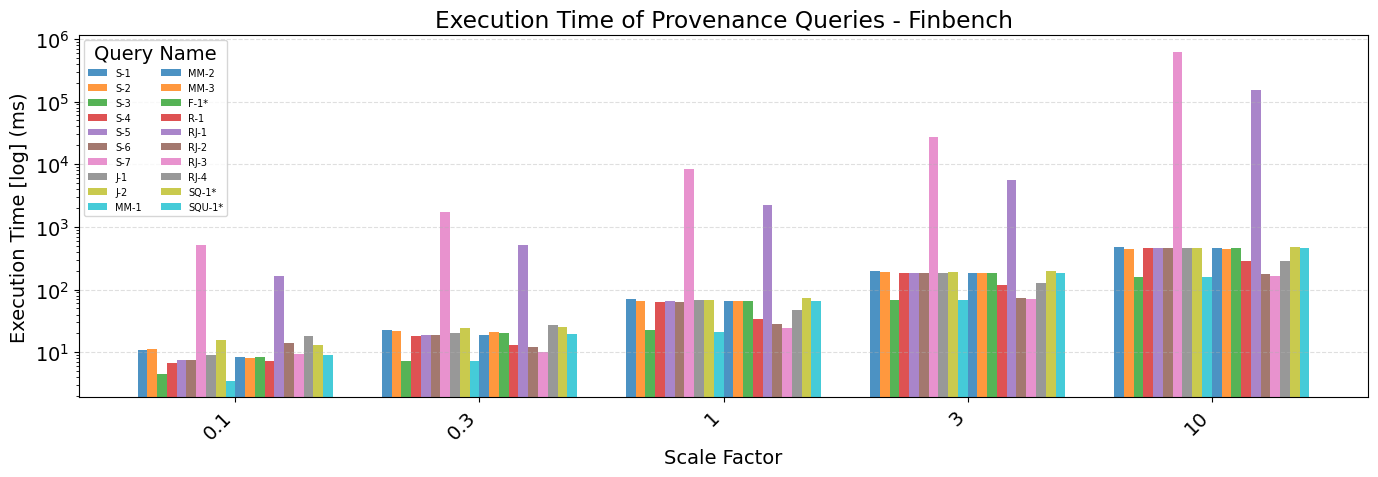

In [58]:
show_exec_times(query_level_times_finbench[query_level_times_finbench["query_type"]=="prov"], finbench_query_order, "Finbench")

**Observations:**
* The provenance execution times increase across scale factors as expected.
* Query ```S-7``` and query ```RJ-1``` have the highest execution times across all scale factors. (Need further exploration to see if the overhead is also high) 

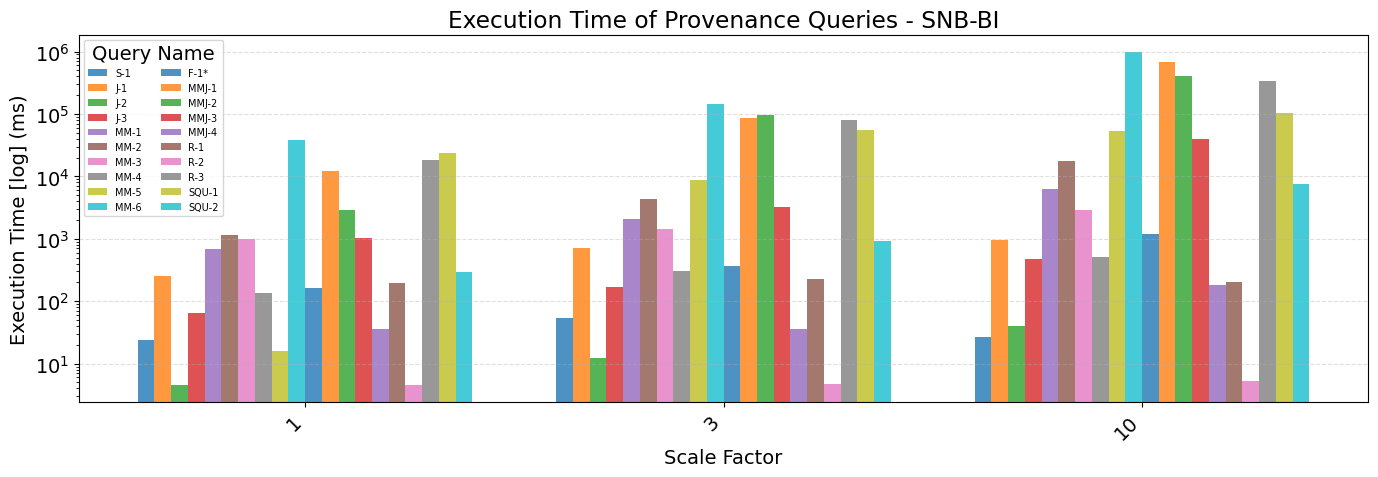

In [59]:
show_exec_times(query_level_times_snb[query_level_times_snb["query_type"]=="prov"], snb_query_order, "SNB-BI")

**Observations:**
* The provenance execution times increase across scale factors as expected.
* Queries ```MM-6, MMJ-1, MMJ-2, R-3``` and ```SQU-1``` have the highest execution times across all scale factors.
* ```R-2``` seem to have the same execution time acorss all scale factors.

## 2. Analyze Overhead

In [76]:
def preprocess_data_for_overhead(query_level_df):
    
    ## compute the relative provenance overhead compared to baseline query as a percentage
    
    perc_overhead = (query_level_df[(query_level_df["query_type"]=="orig") | (query_level_df["query_type"]=="prov")])

    perc_overhead_pivoted = perc_overhead.pivot_table(
        index=["dataset", "scale_factor","query_number", "query_name"],
        columns="query_type",
        values="total_execution_time",
        aggfunc="mean"
    ).reset_index()
    
    perc_overhead_pivoted["overhead"] = perc_overhead_pivoted["prov"] - perc_overhead_pivoted["orig"]
    perc_overhead_pivoted["percentage_overhead"] = (perc_overhead_pivoted["prov"] - perc_overhead_pivoted["orig"])*100/perc_overhead_pivoted["orig"]

    return perc_overhead_pivoted
    

In [116]:
def show_prov_overheads(plot_details, df):
    
    query_groups = plot_details["query_groups"]
    all_vals = df[plot_details["plot_column"]]
    
    Y_MIN = all_vals.min() * 1.1  # include negatives
    Y_MAX = all_vals.max() * 1.05

    scale_factors = sorted(df["scale_factor"].unique())
    n_groups = len(query_groups)

    fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 3), sharey=True)
    if n_groups == 1:
        axes = [axes]

    for i, (group_name, queries) in enumerate(query_groups.items()):

        ax = axes[i]
        queries = [q for q in queries if q in df["query_name"].values]

        colors = plt.colormaps['tab20'].resampled(len(queries))

        for j, query in enumerate(queries):
            query_data = df[df["query_name"] == query].set_index("scale_factor")
            overhead = query_data[plot_details["plot_column"]].reindex(scale_factors)
            ax.plot(scale_factors, overhead, marker='o', linestyle='-',
                    label=query, markersize=4, color=colors(j))
            

        ax.set_yscale("symlog")
        ax.set_ylim(Y_MIN, Y_MAX)

        # Set y-axis label only for the left most
        if i == 0:
            ax.set_ylabel(plot_details["y_label"])
            ax.yaxis.set_label_coords(-0.15, 0.55)
            
        ax.set_title(group_name, fontweight='bold', fontsize=14 )
        ax.grid(True, which="major", linestyle="--", linewidth=0.7)
        ax.legend(title='Query', fontsize=10, ncol=1, bbox_to_anchor=(1.05, 1.05), loc='upper left')

        ax.set_xticks([0, 2, 4, 6, 8, 10])
        ax.set_xticklabels([0, 2, 4, 6, 8, 10])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))

    plt.tight_layout(rect=[0,0,1,0.95])
    # filename = f"./result/plots/{plot_details["dataset_name"]}_prov_overhead-all.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


### 2.A. Absolute Provenance Overhead

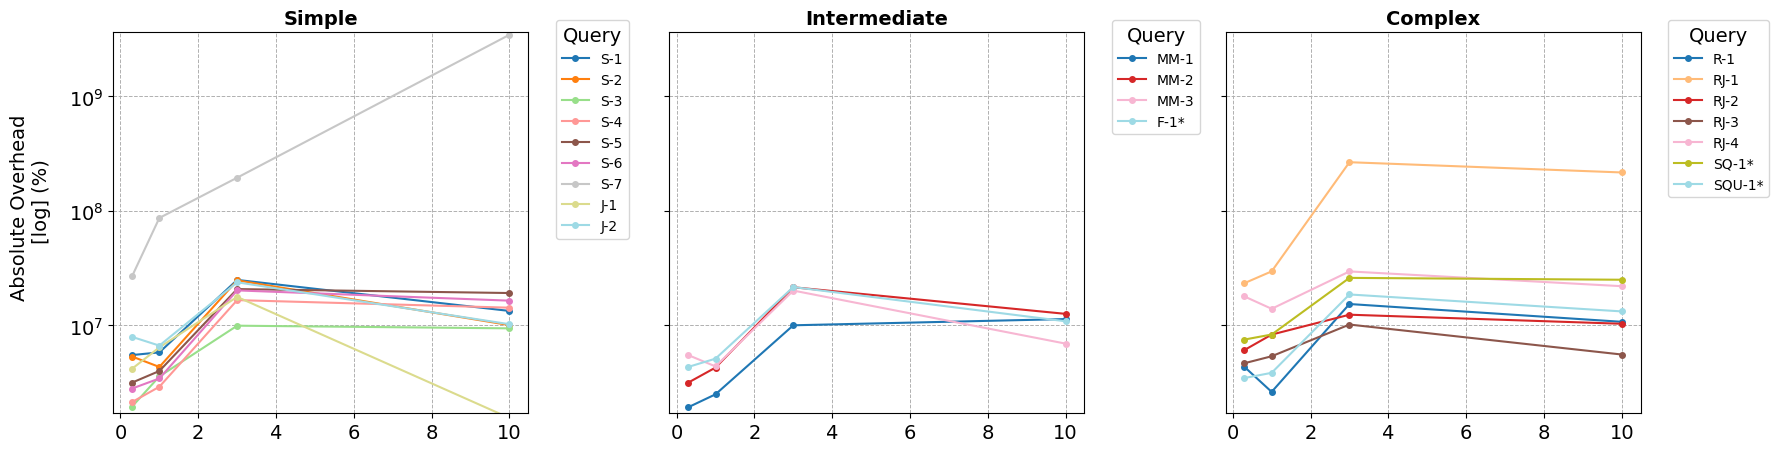

In [78]:
finbench_plot_details = { "query_groups": finbench_query_groups,
             "y_label": "Absolute Overhead \n [log] (%)",
             "plot_column": "overhead",
             "dataset_name":"finbench"
              }

finbench_overhead = preprocess_data_for_overhead(query_level_times_finbench)
show_prov_overheads(finbench_plot_details, finbench_overhead[finbench_overhead["scale_factor"]!=0.1])

**Observations:**
* Overall, the absolute overhead seem to stabilize as the scale factor grows.
* The absolute overheads of ```S-7``` and ```RJ-1``` stand out.
* ```J-1, J-2, RJ-3``` and ```MM-3``` have large decreases at scale factor 10.

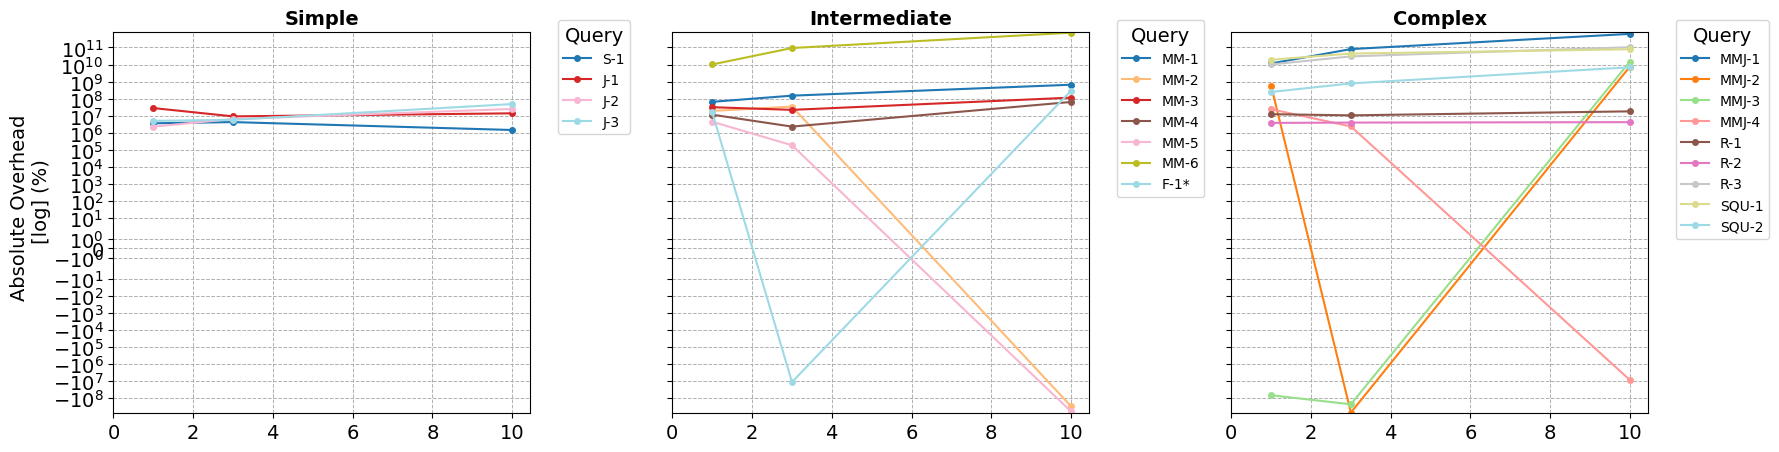

In [79]:
snb_plot_details = { "query_groups": snb_query_groups,
             "y_label": "Absolute Overhead \n [log] (%)",
             "plot_column": "overhead",
             "dataset_name":"snb"
                
              }

snb_overhead = preprocess_data_for_overhead(query_level_times_snb)
show_prov_overheads(snb_plot_details, snb_overhead)

**Observations:**
* The overhead seem to grow across scale factors for most queries. (However this needs to be explored relative to the baseline queries to understand how the provenance computation contributes to the overhead growth across scale factors)
* Large negative overheads can be observed for queries ```F-1*, MM-2, MM-5, MMJ-3, MMJ-2``` and ```MMJ-4```.
* ```MM-6, MMJ-1,``` and ```SQU-1``` have the highest absolute overheads. 

#### Explore negative and dips in the overhead

In [176]:
def show_overhead_breakdown(df, query_groups):

    pivoted = df.pivot_table(
        index=["scale_factor", "query_name", "parameter"],
        columns="query_type",
        values="total_execution_time"
    ).reset_index()
    
    pivoted["overhead"] = ((pivoted["prov"] - pivoted["orig"]))
    pivoted["overhead_pos"] = ((pivoted["prov"] - pivoted["orig"]).clip(lower=0))
    pivoted["overhead_neg"] = ((pivoted["orig"] - pivoted["prov"]).clip(lower=0))

    ## total overhead breakdown (positive and negative) per query
    agg = pivoted.groupby(
        ["scale_factor", "query_name"],
        as_index=False
    ).agg(
        overhead=("overhead", "mean"),
        overhead_pos=("overhead_pos", "mean"),
        overhead_neg=("overhead_neg", "mean")
    )
        
    scale_factors = sorted(agg["scale_factor"].unique())
    n_groups = len(query_groups)
    
    fig, axes = plt.subplots(
        n_groups, 3,
        figsize=(15, 5 * n_groups),
        sharex=True
    )
    
    if n_groups == 1:
        axes = [axes]
    
    # ---- compute global y-limits across all three panels
    all_vals = pd.concat([
        agg["overhead"].dropna(),
        agg[agg["overhead_pos"]>0]["overhead_pos"].dropna(),
        agg[agg["overhead_neg"]>0]["overhead_neg"].abs().dropna()
    ])

    y_min = all_vals.min() * 1.1  # include negatives
    y_max = all_vals.max() * 1.05
    
    for i, (group_name, queries) in enumerate(query_groups.items()):
    
        ax_total = axes[i][0]
        ax_pos = axes[i][1]
        ax_neg = axes[i][2]
    
        # Keep only queries that exist in this dataset/model
        queries = [q for q in queries if q in agg["query_name"].values]
    
        colors = plt.colormaps['tab20'].resampled(len(queries))
    
        for j, query in enumerate(queries):
    
            query_data = agg[
                agg["query_name"] == query
                ].set_index("scale_factor")
    
            total = query_data["overhead"].reindex(scale_factors)
            pos = query_data["overhead_pos"].reindex(scale_factors)
            neg = query_data["overhead_neg"].reindex(scale_factors).abs()
    
            # total = total.where(total > 0)
            pos = pos.where(pos > 0)
            neg = neg.where(neg > 0)
    
            # ---- plot total
            ax_total.plot(
                scale_factors, total,
                marker='o',
                linestyle='-',
                label=query,
                markersize=4,
                color=colors(j)
            )
    
            # ---- plot slowdowns (+)
            ax_pos.plot(
                scale_factors, pos,
                marker='o',
                linestyle='-',
                label=query,
                markersize=4,
                color=colors(j)
            )
    
            # ---- plot speedups (-)
            ax_neg.plot(
                scale_factors, neg,
                marker='o',
                linestyle='-',
                label=query,
                markersize=4,
                color=colors(j)
            )
    
        k=0
        for ax, title in zip([ax_total, ax_pos, ax_neg],
                             [f"{group_name} – Total",
                              f"{group_name} - (+)",
                              f"{group_name} - (−)"]):
            ax.set_yscale("symlog")
            ax.set_ylim(y_min, y_max)
            ax.set_title(title, fontweight='bold')
            ax.grid(True, linestyle="--", alpha=0.4)
            if i == n_groups - 1:
                ax.set_xlabel("Scale Factor")
            if k == 0:
                ax.set_ylabel("Overhead (ms, log)")
            k+=1
    
        ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

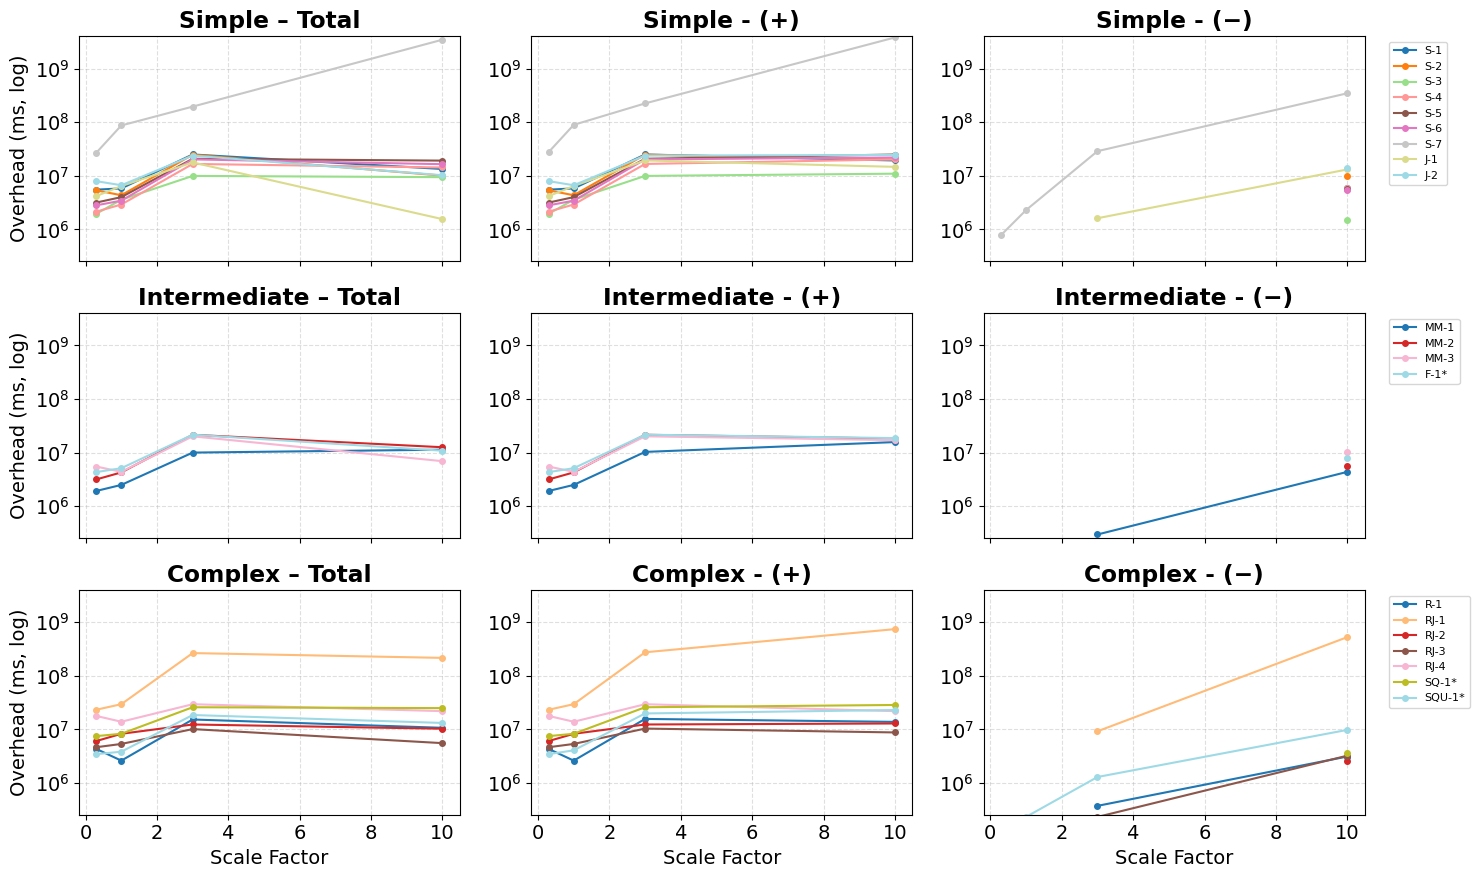

In [175]:
show_overhead_breakdown(parameter_level_times_finbench[parameter_level_times_finbench["scale_factor"]!=0.1], finbench_query_groups)

**Observations:**
* Decreases in absolute overhead of ```J-1, J-2, RJ-3``` and ```MM-3``` can be explained by the negative overheads.
* Most queries have both positive and negative overheads across parameters across all query categories.
* However, overall the positive counterpart of the absolute overhead still seem to stabalize as the data grows.

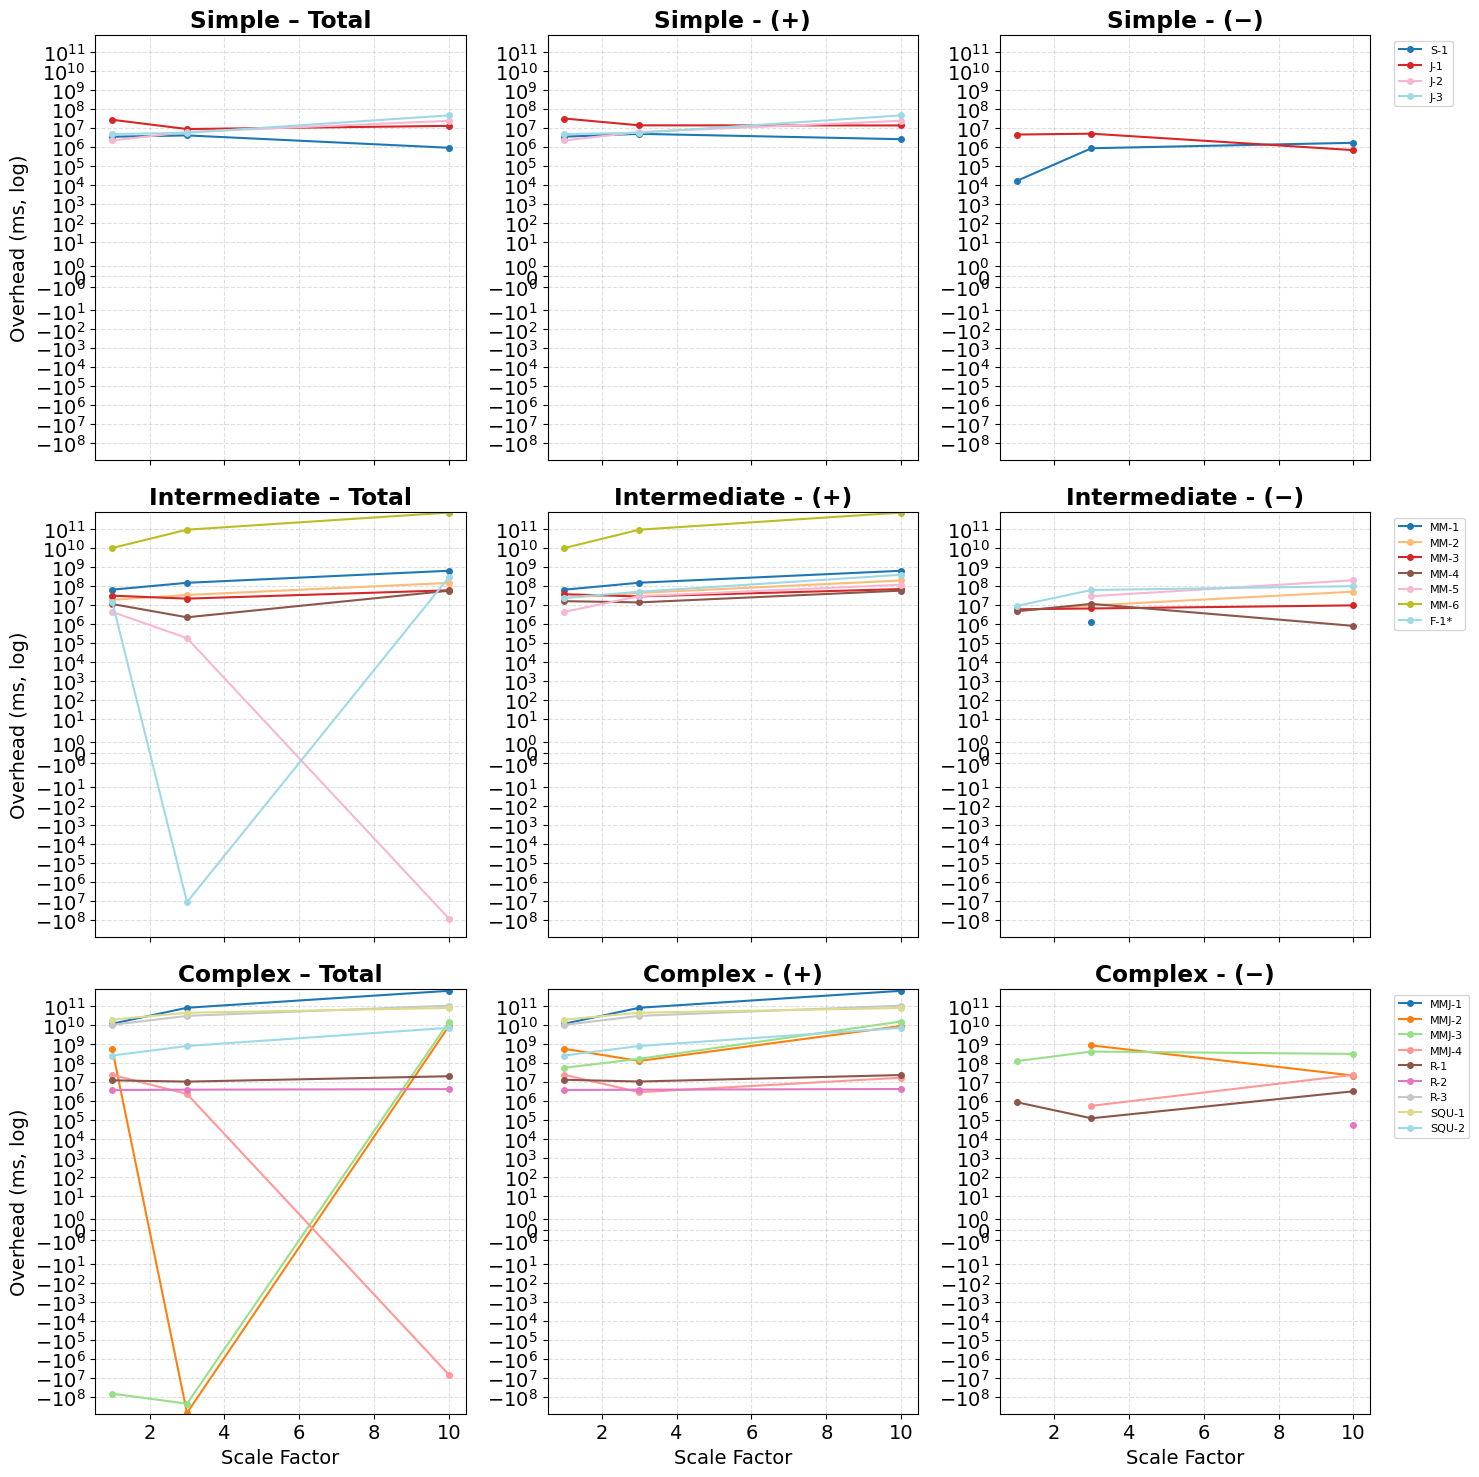

In [177]:
show_overhead_breakdown(parameter_level_times_snb, snb_query_groups)

**Observations:**
* In addition to the queries that have negative total overheads, most other queries also have negative counterparts.

### 2.B. Percentage Provenance Overhead (Compared to baseline queries)

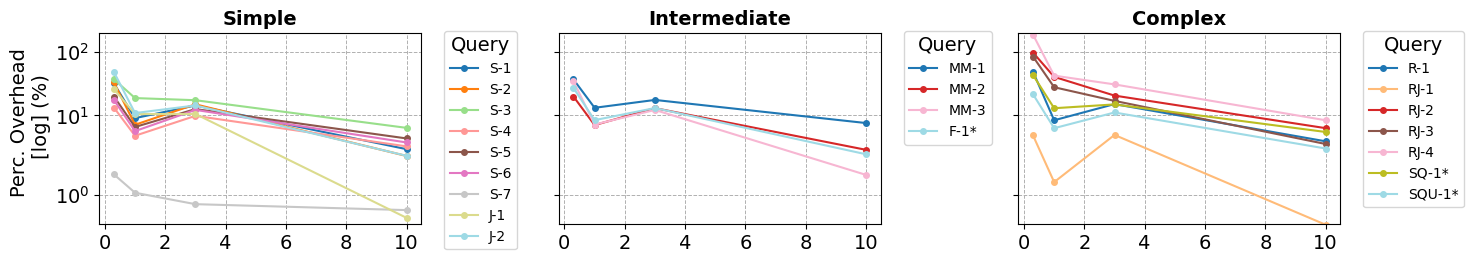

In [117]:
finbench_plot_details = { "query_groups": finbench_query_groups,
             "y_label": "Perc. Overhead \n [log] (%)",
             "plot_column": "percentage_overhead",
             "dataset_name":"finbench"
              }

finbench_overhead = preprocess_data_for_overhead(query_level_times_finbench)
show_prov_overheads(finbench_plot_details, finbench_overhead[finbench_overhead["scale_factor"]!=0.1])

**Observations:**
* The relative overhead compared to the baseline queries rapidly decreases with increasing scale factor.
* The relative overhead varies at low scale factors across all query categories.
* The overheads at higher scales converges to below 10%.

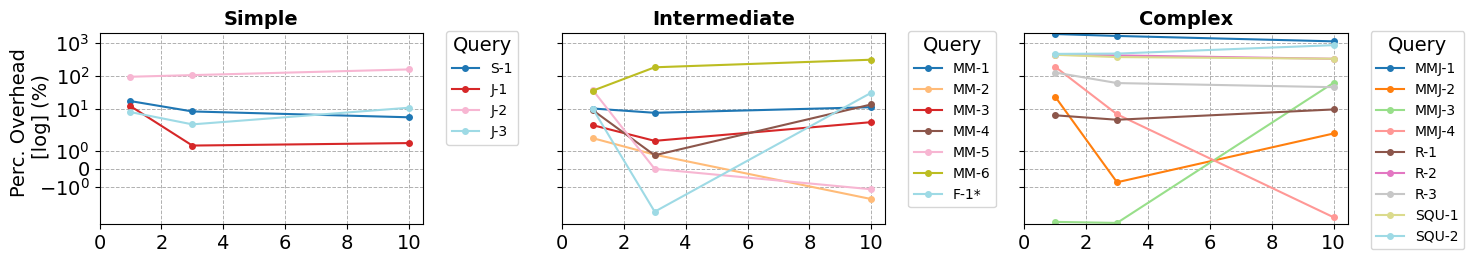

In [168]:
snb_plot_details = { "query_groups": snb_query_groups,
             "y_label": "Perc. Overhead \n [log] (%)",
             "plot_column": "percentage_overhead",
             "dataset_name":"snb"
                
              }

snb_overhead = preprocess_data_for_overhead(query_level_times_snb)
show_prov_overheads(snb_plot_details, snb_overhead)

**Observations:**
* Overall, the relative overhead seem to stabilize as the data grows.
* Relative overheads for ```J-2, MM-6, MMJ-1, SQU-1``` and ```SQU-2``` have the highest overheads across all scale factors.
* Queries ```F-1*, MM-2, MM-5, MMJ-2, MMJ-3``` and ```MMJ-4``` have negative relative overheads.
* Unexpected drop in ```J-3```.